## Vježbe 7

Danas:
- vidjeti što znače underfitting i overfitting
- odabrati pravi model, primjerice biranjem stupnja polinoma pomoću validacijskog skupa
- vidjeti kako regularizacija utječe na model
- usporediti zatvoreno rješenje i iterativni pristup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

## 1. Generiranje podataka

Napravit ćemo jednostavan 1D problem koji je nelinearan pa model stupnja 1 neće biti dovoljan.
Podatke ovoga puta ne dijelimo samo na trening i test, nego dodajemo i validacijski skup. Omjer kojeg ćemo se držati bit će 80:10:10 za trening, validaciju i test.

In [2]:
np.random.seed(42)
X=np.random.rand(1000, 1) * 6-3
y=0.5*X[:,0]**3 - X[:,0]**2 + 2*X[:,0] + np.random.randn(1000)*2.5

In [3]:
#1 korak
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
#2 korak - pola pola
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

print(X_train.shape[0])
print(X_test.shape[0])
print(X_val.shape[0])

800
100
100


## 2. Polinomna regresija

Iz jedne varijable $x$ napravimo nove značajke $x$, $x^2$, ..., $x^d$.

Nakon toga na prošireni skup primijenimo običnu linearnu regresiju. To je najjednostavniji način da dobijemo polinomni model bez pisanja vlastite klase. U tu svrhu koristit ćemo alat `PolynomialFeatures`, koji omogućuje računanje svih potencija do stupnja $d$.

In [6]:
poly = PolynomialFeatures(degree=4, include_bias=False)
x_demo=np.array([[2.0]])
poly.fit_transform(x_demo)


array([[ 2.,  4.,  8., 16.]])

Nacrtajmo sada podatke da vidimo što smo dobili i izgleda li takav odnos doista kao polinom višeg stupnja.

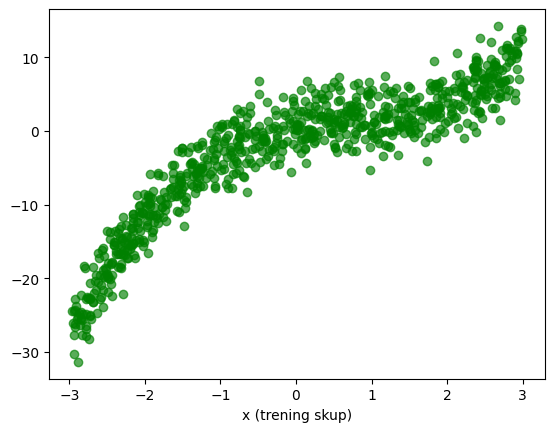

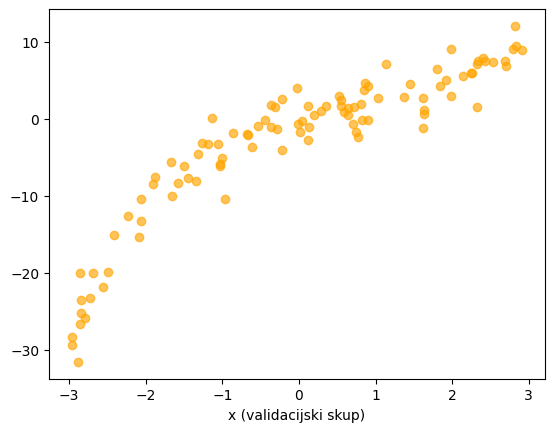

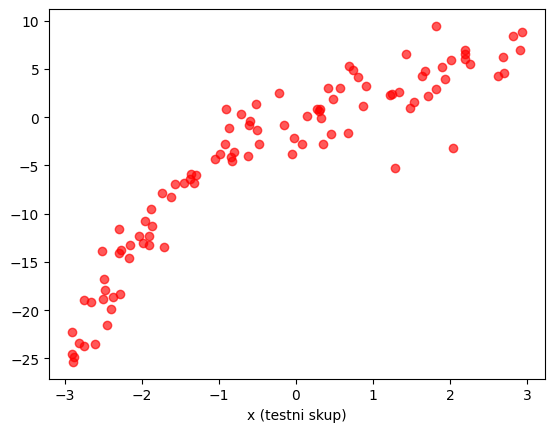

In [7]:
plt.scatter(X_train[:, 0], y_train, label="trening", alpha=0.65, color="green")
plt.xlabel("x (trening skup)")
plt.show()
plt.scatter(X_val[:, 0], y_val, label="validacija", alpha=0.65, color="orange")
plt.xlabel("x (validacijski skup)")
plt.show()
plt.scatter(X_test[:, 0], y_test, label="test", alpha=0.65, color="red")
plt.xlabel("x (testni skup)")
plt.show()

## 3. Jednostavnija implementacija

Umjesto vlastite klase koristimo `Pipeline` iz paketa `scikit-learn`.

Pipeline će ovdje imati tri koraka:
- `PolynomialFeatures` proširuje ulaz
- `StandardScaler` drži značajke na sličnoj skali
- zadnji korak je regresijski model koji želimo isprobati

Tako dobivamo isti workflow uz puno manje koda.

### Pomoćne funkcije

U nastavku definiramo malu pomoćnu funkciju za slaganje polinomnog modela, ispis MSE-a i crtanje aproksimacije.

In [9]:
def make_poly_model(degree, estimator=None):
    if estimator is None:
        estimator = LinearRegression()
    
    return Pipeline(
        steps=[
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)), 
            ("scaler", StandardScaler()),
            ("model", estimator)
        ]
    )

def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

def print_metrics(label,model, X_train, y_train, X_val,y_val):
    training_mse = mse(y_train,model.predict(X_train))
    val_mse = mse(y_val, model.predict(X_val))
    print(label)
    print(f"Trening MSE : {training_mse}")
    print(f"Val MSE : {val_mse}")

def plot_model(ax, model, X, y, title, color="tab:red"):
    xs = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
    ax.scatter(X[:, 0], y, alpha=0.85)
    ax.plot(xs[:, 0], model.predict(xs), color=color, linewidth=2.5)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

In [11]:
demo_model = make_poly_model(degree=5)
print(demo_model)

Pipeline(steps=[('poly', PolynomialFeatures(degree=5, include_bias=False)),
                ('scaler', StandardScaler()), ('model', LinearRegression())])


## 4. Underfitting

Ako je stupanj premalen, model nema dovoljno fleksibilnosti. Za `d = 1` dobivamo praktički pravac.

In [13]:
underfit_model = make_poly_model(degree=1)
underfit_model.fit(X_train, y_train)

print_metrics("Model 1 stupnja", underfit_model, X_train, y_train, X_val, y_val)

Model 1 stupnja
Trening MSE : 17.710051761447993
Val MSE : 19.49785494715651


Kod underfittinga su i pogreška na trening skupu i pogreška na validacijskom skupu relativno visoke.
Problem nije u regularizaciji, nego u premalom kapacitetu modela.

## 5. Overfitting

Ako dignemo stupanj previsoko, model može početi pratiti šum.
Tada pogreška na skupu za učenje pada, ali pogreška na validacijskom skupu često raste.

In [17]:
overfit_model = make_poly_model(degree=15)
overfit_model.fit(X_train, y_train)
print_metrics("Model stupnja 15 ", overfit_model, X_train, y_train, X_val, y_val)

Model stupnja 15 
Trening MSE : 6.116724041017906
Val MSE : 5.585977009571211


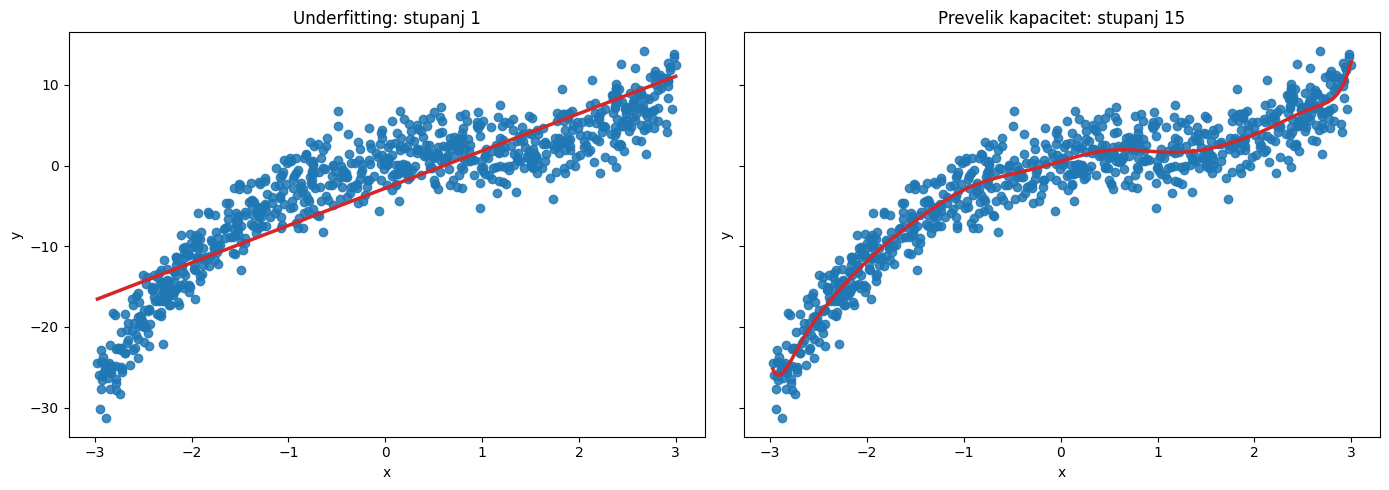

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_model(axes[0], underfit_model, X_train, y_train, "Underfitting: stupanj 1", color="tab:red")
plot_model(axes[1], overfit_model, X_train, y_train, "Prevelik kapacitet: stupanj 15", color="tab:red")
plt.tight_layout()
plt.show()

## 6. Biranje stupnja pomoću validacijskog skupa

Isprobamo više stupnjeva i uzmemo onaj koji ima najmanji validacijski MSE.

In [28]:
degrees = list(range(1,16))
train_scores = []
val_scores = []
models_by_degree={}

for degree in degrees:
    candidate = make_poly_model(degree=degree)
    candidate.fit(X_train,y_train)
    train_scores.append(mse(y_train,candidate.predict(X_train)))
    val_scores.append(mse(y_val,candidate.predict(X_val)))
    models_by_degree[degree]=candidate

best_index = int(np.argmin(val_scores))
best_index
best_degree = degrees[best_index]
best_model=models_by_degree[best_degree]

best_index, best_degree, best_model

print(f"Train MSE: ",train_scores[best_index])
print(f"VAL MSE: ", val_scores[best_index])

Train MSE:  6.2619991236405
VAL MSE:  5.105721424200346


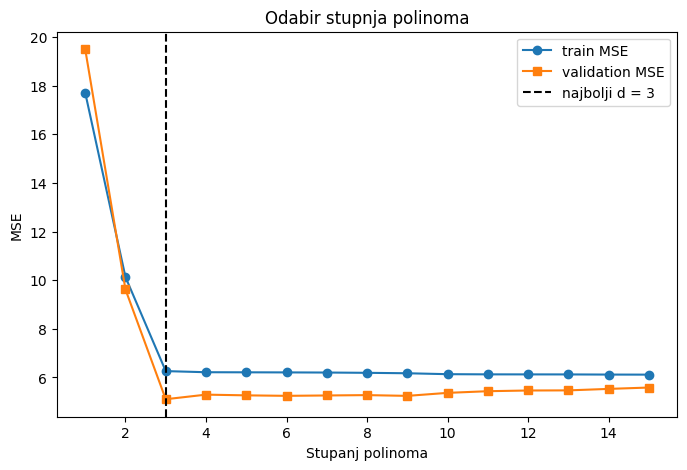

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(degrees), train_scores, marker="o", label="train MSE")
ax.plot(list(degrees), val_scores, marker="s", label="validation MSE")
ax.axvline(best_degree, color="black", linestyle="--", label=f"najbolji d = {best_degree}")
ax.set_xlabel("Stupanj polinoma")
ax.set_ylabel("MSE")
ax.set_title("Odabir stupnja polinoma")
ax.legend()
plt.show()

## 7. Regularizacija

Ako želimo zadržati viši stupanj, regularizacija može smiriti model.

Ridge minimizira

$$
J(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2 + \alpha \sum_{j=1}^{p} w_j^2
$$

Lasso minimizira

$$
J(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2 + \alpha \sum_{j=1}^{p} \left|w_j\right|
$$

Usporedimo tri modela na namjerno previsokom stupnju `d = 15`.

In [32]:
high_degree=15
no_reg_model = make_poly_model(degree=high_degree)
l2_model = make_poly_model(degree=high_degree, estimator=Ridge(alpha=0.1))
l1_model = make_poly_model(degree=high_degree, estimator=Lasso(alpha=0.03, max_iter=20000))
for label,model in [
    ("Bez reg.", no_reg_model),
    ("L1",l1_model),
    ("L2", l2_model)
]:
    model.fit(X_train,y_train)
    print_metrics(label, model, X_train, y_train, X_val,y_val)

Bez reg.
Trening MSE : 6.116724041017906
Val MSE : 5.585977009571211
L1
Trening MSE : 6.231857240561697
Val MSE : 5.1921927949778865
L2
Trening MSE : 6.155272881457075
Val MSE : 5.307280654813169


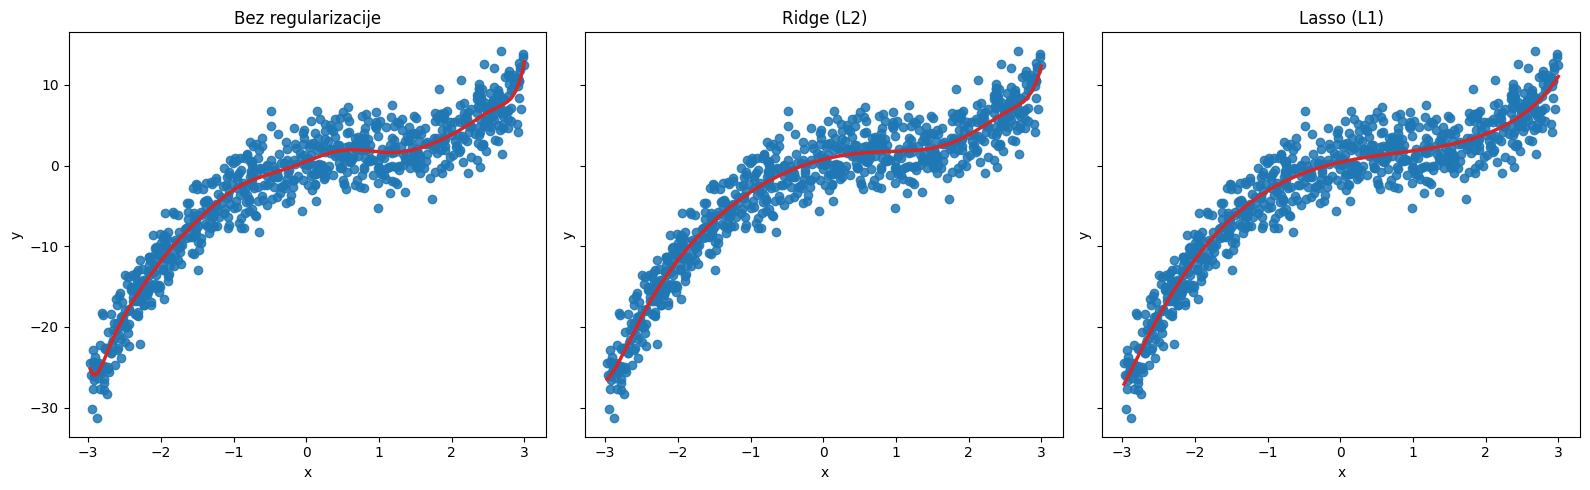

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
plot_model(axes[0], no_reg_model, X_train, y_train, "Bez regularizacije", color="tab:red")
plot_model(axes[1], l2_model, X_train, y_train, "Ridge (L2)", color="tab:red")
plot_model(axes[2], l1_model, X_train, y_train, "Lasso (L1)", color="tab:red")
plt.tight_layout()
plt.show()

## 8. Finalna evaluacija

Testni skup diramo tek na kraju.
Finalni model treniramo na `train` koristeći stupanj koji je odabrao validacijski skup.

Testni MSE za najbolji model:  {5.662167900083419}


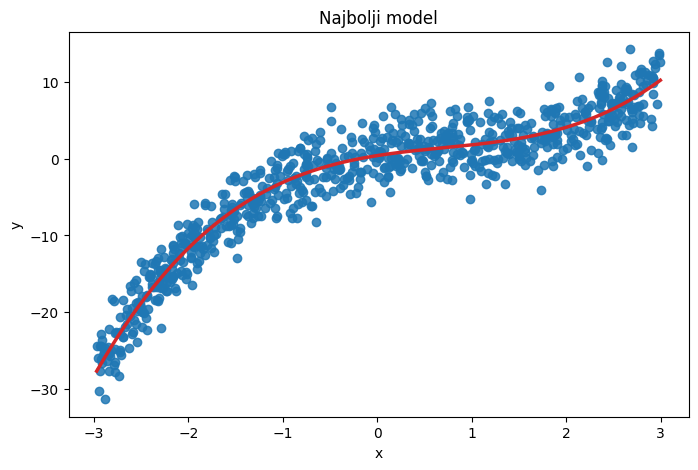

In [40]:
fix, axes = plt.subplots(figsize=(8,5))
final_model=make_poly_model(degree=best_degree)
final_model.fit(X_train,y_train)
test_mse = mse(y_test, final_model.predict(X_test))
print(f"Testni MSE za najbolji model: ", {test_mse})

plot_model(
    axes,
    final_model,
    X_train, 
    y_train,
    "Najbolji model",
    color="tab:red", 
)
plt.show()